# Frozen-grid inventory impact v1

This notebook validates the implementation-facing economics of one inventory-impact formula. It contains no design chronology and evaluates no alternate production coordinate.

## Economic mandate

The inventory fee has one job: compensate PLPs for marginal portfolio risk that fair contract pricing and the ordinary spread do not already cover.

A trade has three economically distinct components:

1. **Fair contract value** pays for expected settlement payout.
2. **Spread and ordinary fees** compensate execution costs, model uncertainty, and expected adverse selection.
3. **Inventory impact** compensates the bad-tail capital created by the resulting portfolio transition.

The PLP north star is expected profit per dollar of economic capital:

$$\text{risk-adjusted return}=\frac{E[\text{PLP P\&L}]}{K}.$$

Dollar profit alone rewards taking more risk. The denominator asks how much capital must remain available for bad settlement outcomes.

## Why centered expected shortfall instead of variance

For frozen settlement outcome `s`, let `P_s` be the pool's payout and let `E_frozen[P]` be expected payout under the market's immutable probability snapshot. The centered loss is

$$X_s=P_s-E_{frozen}[P].$$

Centering recognizes that traders pay the pool when they buy positions. The pool's capital exposure is not gross payout by itself; it is bad-outcome payout net of the economic value already collected through contract pricing. If traders cover every frozen outcome equally and the pool will pay $1,000 in every bucket, it also receives approximately $1,000 of contract value: the top-five payout and `E_frozen[P]` are both $1,000, so `K95_grid = 0`. A gross-payout coordinate would report $1,000 of risk even though settlement has no uncertainty.

The protocol does not center on historical cash collected at each live entry price. That amount depends on trade path, live oracle state, spread, and fee components, so identical payout books could produce different inventory potentials and reopen price-path-dependent refund behavior. `E_frozen[P]` instead values every order against the market's immutable probability snapshot, keeping the coordinate a deterministic function of frozen market state while remaining close enough for `B_K` and `r_K` calibration to absorb approximation error.

Variance and standard deviation treat upside and downside symmetrically. Predict payouts are asymmetric: capital is required for large downside outcomes, while equally large favorable deviations do not create the same funding obligation. Variance can also rise when harmless diversification adds upside dispersion. Expected shortfall instead asks for the average centered loss in the worst tail and remains sensitive to the breadth and severity of bad outcomes beyond a percentile cutoff.

The implementation uses a frozen-grid approximation of 95% expected shortfall: the average payout in the worst five 1%-probability buckets minus frozen expected payout.

## What payout liability `L` does—and what it lacks as a fee coordinate

The existing payout-liability measure is

$$L=M+\lambda(T-M),$$

where `M` is maximum payout at any settlement point, `T` is aggregate maximum payout across positions, and `λ(T−M)` is a liquidity buffer.

`L` remains valuable and unchanged for solvency. `M` guarantees that every settlement outcome can be paid, while the buffer supports live exits for positions that do not overlap the current worst point.

Those backing duties do not make `L` a complete investor-risk coordinate:

- it contains no settlement probabilities;
- it does not measure the breadth of the bad tail;
- it does not measure covariance with the existing portfolio;
- `T` can rise when a trade diversifies the book and lowers centered tail capital; and
- its configured scale and rate are not denominated in investor economic capital.

Using `L` for both backing and inventory compensation can therefore charge a taker for liquidity reserve growth even when the transition creates no additional bad-tail capital. V1 keeps `L` for backing and gives inventory impact one separate frozen-grid capital coordinate. The two are accounting responsibilities, not stacked taker fees.

## V1 coordinate

Each market freezes 100 consecutive settlement buckets representing 1% probability each under one authenticated pricing snapshot. Bucket `i` stores the maximum payout attainable anywhere in that price interval. The centered bad-tail coordinate is

$$K_{95}^{grid}=\operatorname{average}(\text{five largest bucket maxima})-E_{frozen}[payout].$$

`E_frozen[payout]` is additive expected payout computed from each order's actual range probability under the same frozen snapshot. Conservative bucket maxima are used only in the bad-tail term, never in centering.

The coordinate feeds one capped potential:

$$\Psi(book)=\Phi_{r_K,B_K}(K_{95}^{grid}(book)).$$

Every voluntary transition that raises `Ψ` pays the full increase. A voluntary risk-reducing close may receive a refund bounded by the potential decrease, remaining market time, its own paid credit, and isolated escrow. `L` remains exclusively a cash-backing measure.

## Notebook flow

### Part 1 — Coordinate behavior

Test pile-on, broad-tail accumulation, diversification, a guaranteed payout, and narrow spikes. Verify that centering removes expected settlement value without allowing conservative bucket maxima to poison the mean.

### Part 2 — Rolling state

Apply a sequence of bucket updates and prove that rolling top-five and expected-payout state matches independent full recomputation after every transition.

### Part 3 — Charges, closes, and vesting

Apply the capped potential to risk-increasing mints, hedge-removing closes, risk-reducing closes, and late openings. Verify that opening charges do not depend on remaining time and refunds cannot exceed position credit or escrow.

### Part 4 — `B_K` and `r_K` sensitivity

Show how the capital-scale parameter controls curvature and how the rate controls magnitude. These are sensitivity inputs, not production calibration.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

N_BUCKETS = 100
TAIL_BUCKETS = 5
TARGET_BUCKET_MASS = 0.01
BUCKET_MASS_TOLERANCE = 0.0001  # One basis point of total probability.

pd.options.display.float_format = "{:,.4f}".format
plt.style.use("seaborn-v0_8-whitegrid")


def validate_bucket_masses(masses):
    masses = np.asarray(masses, dtype=float)
    return (
        len(masses) == N_BUCKETS
        and np.isclose(masses.sum(), 1.0)
        and np.all(np.abs(masses - TARGET_BUCKET_MASS) <= BUCKET_MASS_TOLERANCE + 1e-15)
    )


def top_five_average(bucket_maxima):
    bucket_maxima = np.asarray(bucket_maxima, dtype=float)
    assert len(bucket_maxima) == N_BUCKETS
    return float(np.partition(bucket_maxima, -TAIL_BUCKETS)[-TAIL_BUCKETS:].mean())


def grid_k95(bucket_maxima, frozen_expected_payout):
    return max(0.0, top_five_average(bucket_maxima) - frozen_expected_payout)


def potential(k_value, risk_rate, capital_scale):
    if k_value <= capital_scale:
        return risk_rate * k_value**2 / (2 * capital_scale)
    return risk_rate * (k_value - capital_scale / 2)


def transition_transfer(k_before, k_after, risk_rate, capital_scale):
    difference = potential(k_after, risk_rate, capital_scale) - potential(
        k_before, risk_rate, capital_scale
    )
    return max(0.0, difference), max(0.0, -difference)


valid_masses = np.full(N_BUCKETS, TARGET_BUCKET_MASS)
invalid_masses = valid_masses.copy()
invalid_masses[0] += 0.0002
invalid_masses[1] -= 0.0002
assert validate_bucket_masses(valid_masses)
assert not validate_bucket_masses(invalid_masses)

assumptions = pd.Series(
    {
        "frozen buckets": N_BUCKETS,
        "target probability / bucket": f"{TARGET_BUCKET_MASS:.2%}",
        "on-chain mass tolerance": f"±{BUCKET_MASS_TOLERANCE:.2%}",
        "tail buckets": TAIL_BUCKETS,
        "tail probability": f"{TAIL_BUCKETS / N_BUCKETS:.0%}",
    },
    name="v1 frozen-grid setting",
)
display(assumptions.to_frame())

,v1 frozen-grid setting
frozen buckets,100
target probability / bucket,1.00%
on-chain mass tolerance,±0.01%
tail buckets,5
tail probability,5%


# Part 1 — Frozen-grid coordinate behavior

Every case below uses the v1 coordinate directly. Bucket maxima conservatively represent bad-tail payouts, while `E_frozen` uses each range's actual frozen probability.

The required behavior is:

- exposure concentrated in five 1% buckets creates substantial `K95_grid`;
- a broad ten-bucket plateau is recognized as tail breadth;
- exposure outside the top five can diversify centered tail capital;
- a guaranteed payout is removed completely by centering; and
- a narrow non-tail spike changes centering only by its actual frozen probability, not by one full bucket of range-max exposure.

,scenario,top-five payout before ($),top-five payout after ($),E_frozen before ($),E_frozen after ($),K95_grid before ($),K95_grid after ($),ΔK95_grid ($)
0,five-bucket pile-on,$0.00,"$1,000.00",$0.00,$50.00,$0.00,$950.00,$+950.00
1,ten-bucket bad-tail plateau,$0.00,$900.00,$0.00,$90.00,$0.00,$810.00,$+810.00
2,guaranteed full-line payout,$0.00,"$1,000.00",$0.00,"$1,000.00",$0.00,$0.00,$+0.00
3,diversifying non-tail exposure,"$1,000.00","$1,000.00",$50.00,$90.00,$950.00,$910.00,$-40.00
4,0.1% narrow non-tail spike,"$1,000.00","$1,000.00",$50.00,$50.50,$950.00,$949.50,$-0.50
5,0.1% narrow tail spike,$0.00,$200.00,$0.00,$1.00,$0.00,$199.00,$+199.00


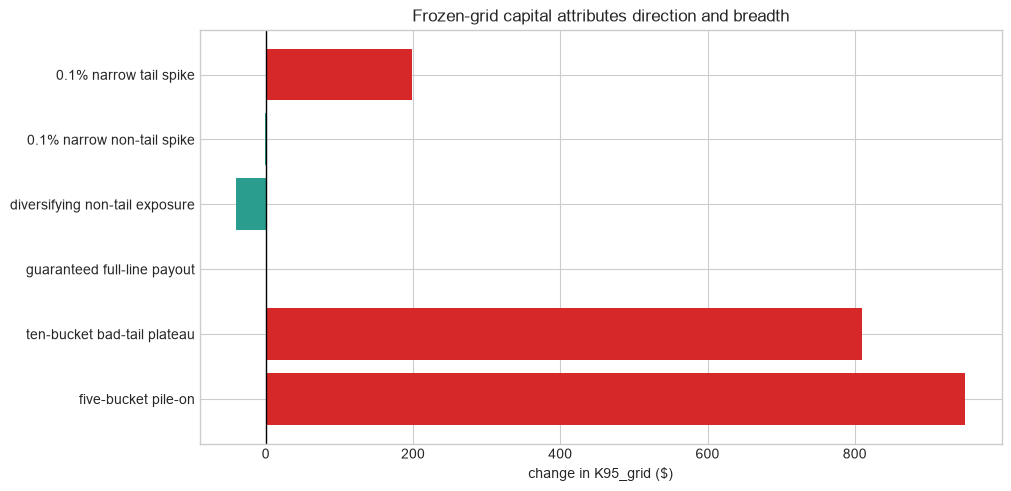

In [2]:
def scenario_row(name, before_maxima, before_expected, after_maxima, after_expected):
    before_k = grid_k95(before_maxima, before_expected)
    after_k = grid_k95(after_maxima, after_expected)
    return {
        "scenario": name,
        "top-five payout before ($)": top_five_average(before_maxima),
        "top-five payout after ($)": top_five_average(after_maxima),
        "E_frozen before ($)": before_expected,
        "E_frozen after ($)": after_expected,
        "K95_grid before ($)": before_k,
        "K95_grid after ($)": after_k,
        "ΔK95_grid ($)": after_k - before_k,
    }


zero = np.zeros(N_BUCKETS)
scenario_rows = []

pile_on = zero.copy()
pile_on[:5] = 1_000
scenario_rows.append(scenario_row("five-bucket pile-on", zero, 0.0, pile_on, 50.0))

plateau = zero.copy()
plateau[:10] = 900
scenario_rows.append(scenario_row("ten-bucket bad-tail plateau", zero, 0.0, plateau, 90.0))

guaranteed = np.full(N_BUCKETS, 1_000.0)
scenario_rows.append(scenario_row("guaranteed full-line payout", zero, 0.0, guaranteed, 1_000.0))

diversified = pile_on.copy()
diversified[20:30] = 400
scenario_rows.append(scenario_row("diversifying non-tail exposure", pile_on, 50.0, diversified, 90.0))

non_tail_spike = pile_on.copy()
non_tail_spike[50] = 500
scenario_rows.append(scenario_row("0.1% narrow non-tail spike", pile_on, 50.0, non_tail_spike, 50.5))

thin_tail_spike = zero.copy()
thin_tail_spike[0] = 1_000
scenario_rows.append(scenario_row("0.1% narrow tail spike", zero, 0.0, thin_tail_spike, 1.0))

coordinate_behavior = pd.DataFrame(scenario_rows)
display(
    coordinate_behavior.style.format(
        {
            column: "${:+,.2f}" if column == "ΔK95_grid ($)" else "${:,.2f}"
            for column in coordinate_behavior.columns
            if column != "scenario"
        }
    ).set_caption("Frozen-grid capital response")
)

results = coordinate_behavior.set_index("scenario")
assert np.isclose(results.loc["five-bucket pile-on", "ΔK95_grid ($)"], 950.0)
assert np.isclose(results.loc["ten-bucket bad-tail plateau", "ΔK95_grid ($)"], 810.0)
assert np.isclose(results.loc["guaranteed full-line payout", "ΔK95_grid ($)"], 0.0)
assert results.loc["diversifying non-tail exposure", "ΔK95_grid ($)"] < 0
assert np.isclose(results.loc["0.1% narrow non-tail spike", "ΔK95_grid ($)"], -0.5)
assert np.isclose(results.loc["0.1% narrow tail spike", "ΔK95_grid ($)"], 199.0)

fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
colors = ["#d62828" if value > 0 else "#2a9d8f" for value in coordinate_behavior["ΔK95_grid ($)"]]
ax.barh(coordinate_behavior["scenario"], coordinate_behavior["ΔK95_grid ($)"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set(title="Frozen-grid capital attributes direction and breadth", xlabel="change in K95_grid ($)")
plt.show()

# Part 2 — Rolling state against an independent payout-curve oracle

The on-chain design stores all 100 bucket maxima and one additive `E_frozen` scalar. Quantile boundaries live in raw settlement-price units so short-expiry 1% masses are not distorted by the coarser order-tick grid. For payout-tree queries, each raw bucket is snapped outward to the tick interval containing every reachable payout state.

An interval order contributes the same payout at every settlement point inside its range. A transition may therefore update a fully covered bucket arithmetically, but every partially covered boundary bucket must be re-queried from the complete payout tree after both opens and closes.

The reference model below does not consume bucket deltas. It stores active interval orders, constructs the complete piecewise-constant payout curve from their endpoints, and independently finds each bucket's maximum. The rolling implementation is checked against that oracle after every transition.

The critical regression has two disjoint peaks inside one bucket. Closing part of the larger left-hand peak makes the untouched right-hand peak become the bucket maximum. Blindly subtracting the close amount from the previous maximum produces the wrong answer; a range-max re-query finds the new peak.

In [3]:
def payout_at(active_orders, quantile):
    return sum(
        order["amount"]
        for order in active_orders.values()
        if order["amount"] > 0 and order["lower"] < quantile <= order["higher"]
    )


def recompute_bucket_maxima(active_orders):
    """Independent oracle over every elementary segment of the payout curve."""
    maxima = np.zeros(N_BUCKETS)
    endpoints = sorted(
        {
            endpoint
            for order in active_orders.values()
            if order["amount"] > 0
            for endpoint in (order["lower"], order["higher"])
        }
    )
    for bucket in range(N_BUCKETS):
        left, right = float(bucket), float(bucket + 1)
        local_breaks = [left] + [x for x in endpoints if left < x < right] + [right]
        probes = [(a + b) / 2 for a, b in zip(local_breaks[:-1], local_breaks[1:])]
        probes.extend(x for x in local_breaks[1:] if left < x <= right)
        maxima[bucket] = max((payout_at(active_orders, x) for x in probes), default=0.0)
    return maxima


def recompute_frozen_expected(active_orders):
    return sum(
        order["amount"] * (order["higher"] - order["lower"]) / N_BUCKETS
        for order in active_orders.values()
        if order["amount"] > 0
    )


def bucket_coverage(lower, higher, bucket):
    left, right = float(bucket), float(bucket + 1)
    overlaps = higher > left and lower < right
    fully_covered = lower <= left and higher >= right
    return overlaps, fully_covered


transitions = [
    ("open", "full", 10.0, 13.0, 400.0, "open fully covered buckets"),
    ("open", "left", 0.05, 0.45, 1_000.0, "open left partial-bucket peak"),
    ("open", "right", 0.55, 0.95, 900.0, "open disjoint right peak in same bucket"),
    ("close", "left", None, None, 500.0, "partially close larger left peak"),
    ("open", "span", 0.25, 2.75, 300.0, "open mixed partial/full range"),
    ("close", "span", None, None, 300.0, "close mixed partial/full range"),
    ("close", "left", None, None, 500.0, "close remaining left peak"),
    ("close", "right", None, None, 900.0, "close right peak"),
    ("close", "full", None, None, 400.0, "close fully covered buckets"),
]

active_orders = {}
rolling_maxima = np.zeros(N_BUCKETS)
rolling_expected = 0.0
rolling_rows = []
partial_close_regression = None

for step, (action, order_id, lower, higher, amount, label) in enumerate(transitions, start=1):
    maxima_before = rolling_maxima.copy()
    if action == "open":
        assert order_id not in active_orders
        active_orders[order_id] = {"lower": lower, "higher": higher, "amount": amount}
        signed_amount = amount
    else:
        order = active_orders[order_id]
        assert 0 < amount <= order["amount"]
        lower, higher = order["lower"], order["higher"]
        order["amount"] -= amount
        signed_amount = -amount

    reference_maxima = recompute_bucket_maxima(active_orders)
    reference_expected = recompute_frozen_expected(active_orders)
    changed_buckets = []
    partial_buckets = []

    for bucket in range(N_BUCKETS):
        overlaps, fully_covered = bucket_coverage(lower, higher, bucket)
        if not overlaps:
            continue
        changed_buckets.append(bucket)
        if fully_covered:
            rolling_maxima[bucket] += signed_amount
        else:
            partial_buckets.append(bucket)
            rolling_maxima[bucket] = reference_maxima[bucket]

    rolling_expected += signed_amount * (higher - lower) / N_BUCKETS

    if label == "partially close larger left peak":
        naive_subtraction = maxima_before[0] - amount
        partial_close_regression = {
            "maximum before close ($)": maxima_before[0],
            "naive previous max - close ($)": naive_subtraction,
            "range-max re-query ($)": reference_maxima[0],
        }
        assert np.isclose(naive_subtraction, 500.0)
        assert np.isclose(reference_maxima[0], 900.0)
        assert not np.isclose(naive_subtraction, reference_maxima[0])

    assert np.all(rolling_maxima >= 0)
    assert np.allclose(rolling_maxima, reference_maxima)
    assert np.isclose(rolling_expected, reference_expected)
    assert np.isclose(
        top_five_average(rolling_maxima),
        np.sort(reference_maxima)[-TAIL_BUCKETS:].mean(),
    )

    rolling_rows.append(
        {
            "step": step,
            "transition": label,
            "fully covered buckets": len(changed_buckets) - len(partial_buckets),
            "re-queried partial buckets": len(partial_buckets),
            "E_frozen ($)": rolling_expected,
            "top-five average ($)": top_five_average(rolling_maxima),
            "K95_grid ($)": grid_k95(rolling_maxima, rolling_expected),
        }
    )

assert partial_close_regression is not None
assert not active_orders or all(order["amount"] == 0 for order in active_orders.values())
assert np.allclose(rolling_maxima, 0.0)
assert np.isclose(rolling_expected, 0.0)

rolling_validation = pd.DataFrame(rolling_rows)
display(
    pd.DataFrame([partial_close_regression]).style.format("${:,.2f}").set_caption(
        "Why a partially covered close must re-query the payout tree"
    )
)
display(
    rolling_validation.style.format(
        {
            "E_frozen ($)": "${:,.2f}",
            "top-five average ($)": "${:,.2f}",
            "K95_grid ($)": "${:,.2f}",
        }
    ).set_caption("Rolling state equals independent full-book payout-curve recomputation")
)
print("All payout-curve oracle, partial-close, top-five, and centering checks passed.")

,maximum before close ($),naive previous max - close ($),range-max re-query ($)
0,"$1,000.00",$500.00,$900.00


,step,transition,fully covered buckets,re-queried partial buckets,E_frozen ($),top-five average ($),K95_grid ($)
0,1,open fully covered buckets,3,0,$12.00,$240.00,$228.00
1,2,open left partial-bucket peak,0,1,$16.00,$440.00,$424.00
2,3,open disjoint right peak in same bucket,0,1,$19.60,$440.00,$420.40
3,4,partially close larger left peak,0,1,$17.60,$420.00,$402.40
4,5,open mixed partial/full range,1,2,$25.10,$540.00,$514.90
5,6,close mixed partial/full range,1,2,$17.60,$420.00,$402.40
6,7,close remaining left peak,0,1,$15.60,$420.00,$404.40
7,8,close right peak,0,1,$12.00,$240.00,$228.00
8,9,close fully covered buckets,3,0,$0.00,$0.00,$0.00


All payout-curve oracle, partial-close, top-five, and centering checks passed.


# Part 3 — Potential transfers and refund vesting

The same capped potential applies to every voluntary transition. Transaction labels do not determine risk direction:

- a mint that raises `K95_grid` pays the full positive potential difference;
- a risk-reducing mint pays no inventory charge and receives no refund;
- a close that removes a hedge and raises `K95_grid` pays the full increase;
- a voluntary close that lowers `K95_grid` may receive a refund; and
- liquidation never receives an inventory refund.

Remaining time never discounts an opening or hedge-removal charge. It only reduces the portion of the position's own paid credit that remains refundable.

In [4]:
REFERENCE_R_K = 0.02
REFERENCE_B_K = 1_000.0


def quote_inventory_transfer(
    transition_type,
    k_before,
    k_after,
    remaining_fraction=1.0,
    remaining_position_credit=0.0,
    escrow=np.inf,
):
    charge, potential_decrease = transition_transfer(
        k_before, k_after, REFERENCE_R_K, REFERENCE_B_K
    )
    refund = 0.0
    if transition_type == "voluntary close" and potential_decrease > 0:
        refund = min(
            potential_decrease,
            remaining_fraction * remaining_position_credit,
            escrow,
        )
    return charge, refund, potential_decrease


open_charge, _, _ = quote_inventory_transfer("mint", 0.0, 950.0)
transition_cases = [
    ("risk-increasing mint", "mint", 0.0, 950.0, 1.0, 0.0, 0.0),
    ("risk-reducing mint", "mint", 950.0, 910.0, 1.0, 0.0, open_charge),
    ("close removes hedge", "voluntary close", 910.0, 950.0, 0.50, 0.0, open_charge),
    ("risk-reducing close", "voluntary close", 950.0, 475.0, 0.50, open_charge, open_charge),
]

transfer_rows = []
for label, transition_type, before, after, remaining, credit, escrow in transition_cases:
    charge, refund, potential_decrease = quote_inventory_transfer(
        transition_type,
        before,
        after,
        remaining,
        credit,
        escrow,
    )
    transfer_rows.append(
        {
            "transition": label,
            "K before ($)": before,
            "K after ($)": after,
            "potential increase charged ($)": charge,
            "potential decrease ($)": potential_decrease,
            "refund paid ($)": refund,
        }
    )

transfer_table = pd.DataFrame(transfer_rows)
display(
    transfer_table.style.format(
        {column: "${:,.4f}" for column in transfer_table.columns if column != "transition"}
    ).set_caption("One potential applied symmetrically to voluntary transitions")
)

assert transfer_table.loc[transfer_table["transition"] == "risk-reducing mint", "refund paid ($)"].eq(0).all()
assert transfer_table.loc[transfer_table["transition"] == "close removes hedge", "potential increase charged ($)"].gt(0).all()
assert transfer_table.loc[transfer_table["transition"] == "risk-reducing close", "refund paid ($)"].gt(0).all()

vesting_rows = []
for remaining_fraction in (1.00, 0.50, 0.25, 0.05):
    late_open_charge, _, _ = quote_inventory_transfer(
        "mint", 0.0, 950.0, remaining_fraction=remaining_fraction
    )
    _, close_refund, potential_decrease = quote_inventory_transfer(
        "voluntary close",
        950.0,
        0.0,
        remaining_fraction=remaining_fraction,
        remaining_position_credit=open_charge,
        escrow=open_charge,
    )
    vesting_rows.append(
        {
            "remaining lifetime": remaining_fraction,
            "opening charge ($)": late_open_charge,
            "potential decrease on full close ($)": potential_decrease,
            "maximum refund ($)": close_refund,
            "vested escrow ($)": late_open_charge - close_refund,
        }
    )

vesting = pd.DataFrame(vesting_rows)
display(
    vesting.style.format(
        {
            "remaining lifetime": "{:.0%}",
            "opening charge ($)": "${:,.4f}",
            "potential decrease on full close ($)": "${:,.4f}",
            "maximum refund ($)": "${:,.4f}",
            "vested escrow ($)": "${:,.4f}",
        }
    ).set_caption("Full opening charge; remaining time limits only refunds")
)

assert vesting["opening charge ($)"].nunique() == 1
assert vesting["maximum refund ($)"].le(open_charge + 1e-12).all()
assert vesting["vested escrow ($)"].ge(-1e-12).all()

,transition,K before ($),K after ($),potential increase charged ($),potential decrease ($),refund paid ($)
0,risk-increasing mint,$0.0000,$950.0000,$9.0250,$0.0000,$0.0000
1,risk-reducing mint,$950.0000,$910.0000,$0.0000,$0.7440,$0.0000
2,close removes hedge,$910.0000,$950.0000,$0.7440,$0.0000,$0.0000
3,risk-reducing close,$950.0000,$475.0000,$0.0000,$6.7688,$4.5125


,remaining lifetime,opening charge ($),potential decrease on full close ($),maximum refund ($),vested escrow ($)
0,100%,$9.0250,$9.0250,$9.0250,$0.0000
1,50%,$9.0250,$9.0250,$4.5125,$4.5125
2,25%,$9.0250,$9.0250,$2.2563,$6.7688
3,5%,$9.0250,$9.0250,$0.4513,$8.5738


# Part 4 — Capital-scale and rate sensitivity

`B_K` and `r_K` are independent policy parameters:

- `B_K` determines the capital level where the marginal rate reaches its cap;
- `r_K` determines that capped marginal rate.

The old liability scale is not reused automatically because frozen-grid capital has a different distribution. Production `B_K` must be derived from stressed market-capital capacity, and `r_K` must be calibrated from the remaining PLP compensation requirement and observed demand.

,B_K ($),r_K,charge for K: 0 → 950 ($),marginal rate at K=950
0,$500,1.0%,$7.000,1.00%
1,$500,2.0%,$14.000,2.00%
2,$500,4.0%,$28.000,4.00%
3,"$1,000",1.0%,$4.513,0.95%
4,"$1,000",2.0%,$9.025,1.90%
5,"$1,000",4.0%,$18.050,3.80%
6,"$2,000",1.0%,$2.256,0.47%
7,"$2,000",2.0%,$4.513,0.95%
8,"$2,000",4.0%,$9.025,1.90%


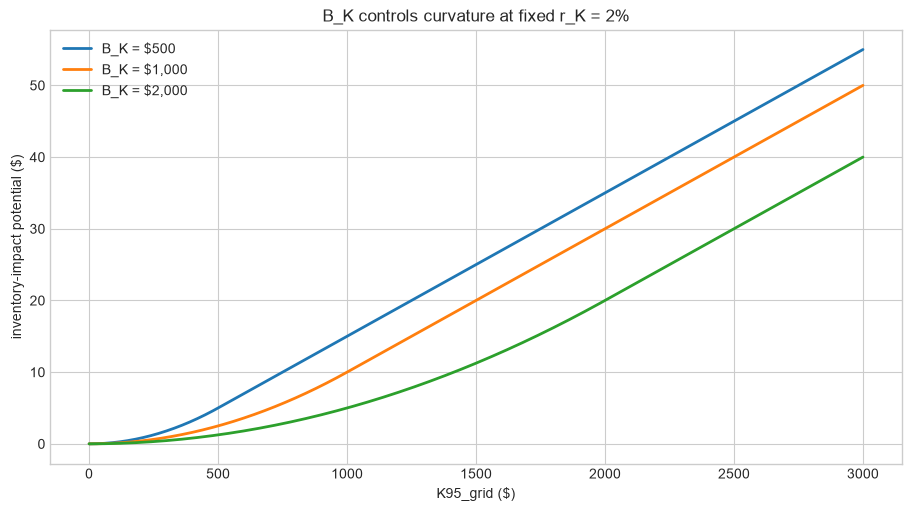

In [5]:
capital_scales = (500.0, 1_000.0, 2_000.0)
risk_rates = (0.01, 0.02, 0.04)

sensitivity_rows = []
for capital_scale in capital_scales:
    for risk_rate in risk_rates:
        sensitivity_rows.append(
            {
                "B_K ($)": capital_scale,
                "r_K": risk_rate,
                "charge for K: 0 → 950 ($)": potential(950.0, risk_rate, capital_scale),
                "marginal rate at K=950": risk_rate * min(950.0 / capital_scale, 1.0),
            }
        )

sensitivity = pd.DataFrame(sensitivity_rows)
display(
    sensitivity.style.format(
        {
            "B_K ($)": "${:,.0f}",
            "r_K": "{:.1%}",
            "charge for K: 0 → 950 ($)": "${:,.3f}",
            "marginal rate at K=950": "{:.2%}",
        }
    ).set_caption("Potential sensitivity; not production calibration")
)

capital_grid = np.linspace(0, 3_000, 301)
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
for capital_scale in capital_scales:
    ax.plot(
        capital_grid,
        [potential(value, REFERENCE_R_K, capital_scale) for value in capital_grid],
        linewidth=2,
        label=f"B_K = ${capital_scale:,.0f}",
    )
ax.set(
    title="B_K controls curvature at fixed r_K = 2%",
    xlabel="K95_grid ($)",
    ylabel="inventory-impact potential ($)",
)
ax.legend()
plt.show()

assert sensitivity["charge for K: 0 → 950 ($)"].gt(0).all()
assert sensitivity["marginal rate at K=950"].le(sensitivity["r_K"] + 1e-12).all()

# Part 5 — Event-based v1 calibration recommendation

Settlement risk is an event exposure, not capital rented by the minute. A bad bucket can consume the complete centered loss whether the market cadence is one minute or one hour. The opening charge therefore has no cadence-time divisor; cadence enters only when realized events and aggregate portfolio capital are measured over a common investor horizon.

## Capital scale `B_K`

Use the notebook's standard harmful transition: 1,000 contracts create `ΔK95_grid = $950`. Set the curvature scale to the next round capital unit:

```text
B_K = $1,000
```

This means one standard five-bucket pile-on traverses 95% of the rising marginal-rate ramp. It avoids the previous mistake of setting `B_K` to total market allocation, which made ordinary harmful transitions negligible relative to the curvature scale. Production monitoring should later replace the reference event with the measured distribution of positive `ΔK` and keep `B_K` near its chosen stress percentile.

## Maximum marginal rate `r_K`

Calibrate the rate over one week:

```text
required weekly inventory compensation = annual PLP hurdle × weekly portfolio K / 52
r_K = required weekly inventory compensation / sum(reference-event potential at r_K = 100%)
```

The prelaunch central case uses `$50,000` of weekly aggregate frozen-grid capital and 30 reference-equivalent positive-risk events across all cadences. Those are explicit policy assumptions, not minute-by-minute rent. They imply an exact 25%-hurdle rate of about `1.78%`; round to a v1 recommendation of:

```text
B_K = $1,000
r_K = 2.00% = 20,000,000 / 1e9
```

The same `r_K` applies to 1-minute, 5-minute, and 1-hour markets. With the reference `ΔK = $950`, it charges `$9.025`, compared directly below with the `$40` base fee on 1,000 contracts. The 20%-30% hurdle range and aggregate-capital/event-count sensitivities show exactly when the recommendation must change.

This is a usable prelaunch parameter recommendation, but enabling it still requires replaying measured frozen-grid transitions through the same formula. Base-fee and spread income are excluded from the inventory-compensation numerator so that expected pricing compensation is not used to excuse uncompensated portfolio tail risk.

In [6]:
WEEKS_PER_YEAR = 52
PLP_HURDLES = (0.20, 0.25, 0.30)
CENTER_PLP_HURDLE = 0.25
RATE_SCALE = 1_000_000_000
DUSDC_SCALE = 1_000_000
BASE_FEE_PER_CONTRACT = 0.04
REFERENCE_CONTRACTS = 1_000
REFERENCE_DELTA_K = float(results.loc["five-bucket pile-on", "ΔK95_grid ($)"])
RECOMMENDED_B_K = 1_000.0
REFERENCE_EQUIVALENT_EVENTS_PER_WEEK = 30
WEEKLY_PORTFOLIO_K = 50_000.0
RECOMMENDED_R_K = 0.02

unit_reference_charge = potential(REFERENCE_DELTA_K, 1.0, RECOMMENDED_B_K)
calibrated_rates = {
    hurdle: (hurdle / WEEKS_PER_YEAR * WEEKLY_PORTFOLIO_K)
    / (REFERENCE_EQUIVALENT_EVENTS_PER_WEEK * unit_reference_charge)
    for hurdle in PLP_HURDLES
}

reference_inventory_charge = potential(
    REFERENCE_DELTA_K, RECOMMENDED_R_K, RECOMMENDED_B_K
)
reference_base_fee = BASE_FEE_PER_CONTRACT * REFERENCE_CONTRACTS
weekly_inventory_compensation = (
    REFERENCE_EQUIVALENT_EVENTS_PER_WEEK * reference_inventory_charge
)
implied_annualized_inventory_return = (
    weekly_inventory_compensation / WEEKLY_PORTFOLIO_K * WEEKS_PER_YEAR
)

recommendation = pd.Series(
    {
        "recommended B_K ($)": RECOMMENDED_B_K,
        "recommended B_K raw DUSDC": round(RECOMMENDED_B_K * DUSDC_SCALE),
        "exact r_K for 20% aggregate hurdle": calibrated_rates[0.20],
        "exact r_K for 25% aggregate hurdle": calibrated_rates[0.25],
        "exact r_K for 30% aggregate hurdle": calibrated_rates[0.30],
        "recommended rounded r_K": RECOMMENDED_R_K,
        "recommended r_K raw 1e9": round(RECOMMENDED_R_K * RATE_SCALE),
        "reference ΔK ($)": REFERENCE_DELTA_K,
        "reference inventory charge ($)": reference_inventory_charge,
        "reference base fee ($)": reference_base_fee,
        "inventory charge / base fee": reference_inventory_charge / reference_base_fee,
        "weekly inventory compensation ($)": weekly_inventory_compensation,
        "implied annualized inventory return": implied_annualized_inventory_return,
    },
    name="event-based v1 recommendation",
)
display(
    recommendation.to_frame().style.format(
        {
            "event-based v1 recommendation": lambda value: (
                f"{value:.2%}" if 0 < value < 1 else f"{value:,.4f}"
            )
        }
    )
)

sensitivity_rows = []
for weekly_k in (25_000.0, 50_000.0, 100_000.0):
    for event_count in (15, 30, 60):
        required_rate = (
            CENTER_PLP_HURDLE / WEEKS_PER_YEAR * weekly_k
        ) / (event_count * unit_reference_charge)
        sensitivity_rows.append(
            {
                "weekly portfolio K ($)": weekly_k,
                "reference-equivalent positive-risk events": event_count,
                "required r_K for 25% hurdle": required_rate,
                "reference charge at required r_K ($)": potential(
                    REFERENCE_DELTA_K, required_rate, RECOMMENDED_B_K
                ),
            }
        )

calibration_sensitivity = pd.DataFrame(sensitivity_rows)
display(
    calibration_sensitivity.style.format(
        {
            "weekly portfolio K ($)": "${:,.0f}",
            "required r_K for 25% hurdle": "{:.2%}",
            "reference charge at required r_K ($)": "${:,.2f}",
        }
    ).set_caption("Aggregate calibration sensitivity; cadence is represented only through event totals")
)

cadence_check = pd.DataFrame(
    {
        "cadence": ["1 minute", "5 minutes", "1 hour"],
        "reference ΔK ($)": [REFERENCE_DELTA_K] * 3,
        "inventory charge ($)": [reference_inventory_charge] * 3,
    }
)
display(
    cadence_check.style.format(
        {"reference ΔK ($)": "${:,.0f}", "inventory charge ($)": "${:,.3f}"}
    ).set_caption("Identical event risk receives an identical opening charge across cadences")
)

assert np.isclose(REFERENCE_DELTA_K, 950.0)
assert np.isclose(reference_inventory_charge, 9.025)
assert np.isclose(reference_base_fee, 40.0)
assert 0.20 < reference_inventory_charge / reference_base_fee < 0.25
assert calibrated_rates[0.20] < RECOMMENDED_R_K < calibrated_rates[0.30]
assert cadence_check["inventory charge ($)"].nunique() == 1
assert 0.25 < implied_annualized_inventory_return < 0.30

print(
    f"Recommendation: B_K=${RECOMMENDED_B_K:,.0f}, r_K={RECOMMENDED_R_K:.2%} "
    f"({RECOMMENDED_R_K * RATE_SCALE:,.0f} / 1e9)."
)
print(
    f"Reference self-check: ΔK=${REFERENCE_DELTA_K:,.0f} charges "
    f"${reference_inventory_charge:,.3f} inventory impact next to "
    f"${reference_base_fee:,.2f} of base fees."
)
print(
    f"Aggregate central case: {REFERENCE_EQUIVALENT_EVENTS_PER_WEEK} events and "
    f"${WEEKLY_PORTFOLIO_K:,.0f} weekly K imply "
    f"{implied_annualized_inventory_return:.2%} inventory compensation."
)

,event-based v1 recommendation
recommended B_K ($),"1,000.0000"
recommended B_K raw DUSDC,"1,000,000,000.0000"
exact r_K for 20% aggregate hurdle,1.42%
exact r_K for 25% aggregate hurdle,1.78%
exact r_K for 30% aggregate hurdle,2.13%
recommended rounded r_K,2.00%
recommended r_K raw 1e9,"20,000,000.0000"
reference ΔK ($),950.0000
reference inventory charge ($),9.0250
reference base fee ($),40.0000


,weekly portfolio K ($),reference-equivalent positive-risk events,required r_K for 25% hurdle,reference charge at required r_K ($)
0,"$25,000",15,1.78%,$8.01
1,"$25,000",30,0.89%,$4.01
2,"$25,000",60,0.44%,$2.00
3,"$50,000",15,3.55%,$16.03
4,"$50,000",30,1.78%,$8.01
5,"$50,000",60,0.89%,$4.01
6,"$100,000",15,7.10%,$32.05
7,"$100,000",30,3.55%,$16.03
8,"$100,000",60,1.78%,$8.01


,cadence,reference ΔK ($),inventory charge ($)
0,1 minute,$950,$9.025
1,5 minutes,$950,$9.025
2,1 hour,$950,$9.025


Recommendation: B_K=$1,000, r_K=2.00% (20,000,000 / 1e9).
Reference self-check: ΔK=$950 charges $9.025 inventory impact next to $40.00 of base fees.
Aggregate central case: 30 events and $50,000 weekly K imply 28.16% inventory compensation.


# Implementation-facing conclusion

The v1 analytics support one coherent implementation:

- 100 immutable, on-chain-verified 1% probability buckets;
- conservative payout-tree range maxima for the five-bucket bad tail;
- additive actual expected payout under the same frozen snapshot for centering;
- arithmetic updates only for fully covered buckets and payout-tree re-queries for partial boundaries;
- rolling state equivalent to independent full piecewise-payout recomputation, including overlapping-peak partial closes;
- one capped potential over `K95_grid`;
- full charges on all voluntary risk-increasing transitions, including hedge-removing closes;
- no inventory refund for risk-reducing mints or liquidation;
- voluntary-close refunds limited by potential decrease, remaining time, position credit, and escrow; and
- a prelaunch recommendation of `B_K = $1,000` and `r_K = 2%`, producing a `$9.025` charge for the `$950` reference capital event regardless of cadence.

The parameter recommendation is conditional on `$50,000` of weekly portfolio capital and 30 reference-equivalent positive-risk events; measured frozen-grid event replay must replace those assumptions before enabling a nonzero production rate. The implementation must additionally pin the notebook oracle against Move payout-tree range-max behavior, partial-close credit rounding, authenticated grid initialization, risk-increasing liquidation policy, overflow bounds, and maximum-book gas/object behavior.